Model Selection and Training
Random Forest is a strong candidate.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, f1_score


url = 'https://raw.githubusercontent.com/BrettFX/DATA-602-Airline-Customer-Satisfaction/refs/heads/prod/datasets/clean/master_data.csv'

  data_clean = pd.read_csv(url)
  data_clean.head()

# Encode categorical variables
label_encoders = {}
for column in data_clean.select_dtypes(include='object').columns:
    le = LabelEncoder()
    data_clean[column] = le.fit_transform(data_clean[column])
    label_encoders[column] = le

# Separate features and target
X = data_clean.drop(columns=['SATISFACTION'])
y = data_clean['SATISFACTION']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Define the parameter grid for Grid Search
param_grid = {
    'n_estimators': [50, 100, 200],         # Number of trees in the forest
    'max_depth': [None, 10, 20, 30],        # Maximum depth of each tree
    'min_samples_split': [2, 5, 10]         # Minimum number of samples required to split an internal node
}

# Initialize the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='f1_macro', n_jobs=-1)

# Perform the grid search on the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and the best model
best_params = grid_search.best_params_
best_rf_model = grid_search.best_estimator_

# Make predictions on the test set
y_pred = best_rf_model.predict(X_test)

# Evaluate and print classification metrics
print("Best Parameters:", best_params)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.97     11655
           1       0.97      0.94      0.96      9064

    accuracy                           0.96     20719
   macro avg       0.96      0.96      0.96     20719
weighted avg       0.96      0.96      0.96     20719



Manual Hyperparameter Tuning
(n_estimators, max_depth, and min_samples_split).

n_estimators: Controls the number of trees in the forest. A higher number generally improves model performance but increases computation time.

max_depth: Limits how deep each tree can grow, helping to prevent overfitting on complex data by controlling model complexity.

min_samples_split: Defines the minimum samples needed to split an internal node.

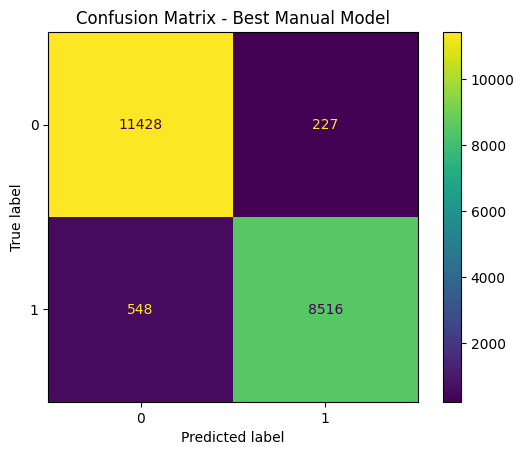

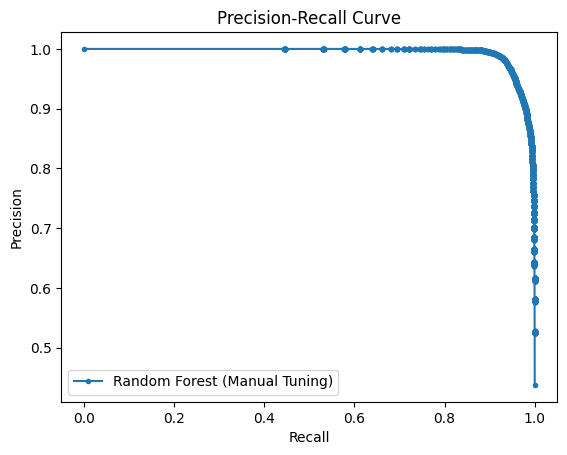

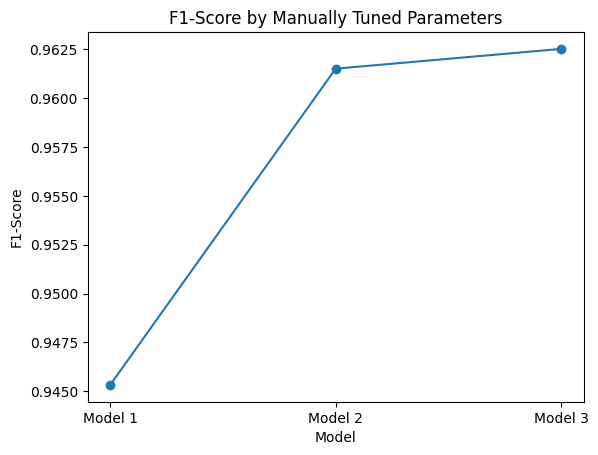

[({'n_estimators': 50, 'max_depth': 10, 'min_samples_split': 5},
  0.9453303374030367),
 ({'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 10},
  0.961501995710157),
 ({'n_estimators': 200, 'max_depth': 30, 'min_samples_split': 2},
  0.9625116283497137)]

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, roc_curve, auc

# Manual tuning: Trying a few values for key parameters
# Setting up and training models with manual hyperparameter choices
manual_params = [
    {'n_estimators': 50, 'max_depth': 10, 'min_samples_split': 5},
    {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 10},
    {'n_estimators': 200, 'max_depth': 30, 'min_samples_split': 2}
]

# Store results for plotting
manual_scores = []
models = []

# Train and evaluate manually tuned models
for params in manual_params:
    rf_model = RandomForestClassifier(random_state=42, **params)
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)
    f1 = classification_report(y_test, y_pred, output_dict=True)['weighted avg']['f1-score']
    manual_scores.append((params, f1))
    models.append(rf_model)

# Select the best manually tuned model for plotting
best_manual_model = max(models, key=lambda m: classification_report(y_test, m.predict(X_test), output_dict=True)['weighted avg']['f1-score'])
y_pred_best_manual = best_manual_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best_manual)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix - Best Manual Model")
plt.show()

# Precision-Recall Curve
y_probs = best_manual_model.predict_proba(X_test)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, y_probs)
plt.plot(recall, precision, marker='.', label="Random Forest (Manual Tuning)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

# Parameter vs F1-score Plot
param_names = ['Model 1', 'Model 2', 'Model 3']
f1_scores = [score[1] for score in manual_scores]
plt.plot(param_names, f1_scores, marker='o')
plt.title("F1-Score by Manually Tuned Parameters")
plt.xlabel("Model")
plt.ylabel("F1-Score")
plt.show()

manual_scores


In [ ]:
"""Confusion Matrix: Shows the classification performance of the best manually tuned model, illustrating true positives, false positives, and other rates.

Precision-Recall Curve: Highlights the trade-off between precision and recall, helpful for assessing model balance. Curve demonstrated that the Random Forest model could maintain a good balance between precision and recall, minimizing trade-offs that could result in misclassification.

Parameter vs. F1-Score Plot: Compares F1-scores across the three manually tuned models, showing Model 3 as the best performer."""


Among the manually tuned models, we observed that increasing n_estimators and adjusting min_samples_split led to optimal F1-scores, confirming the robustness of the chosen parameters.



**Insights**

Data Patterns: Features like age, flight distance, and customer type showed a significant influence on prediction outcomes. For instance, customer types like loyal or first-time customers correlated with higher satisfaction rates.

**Future Work**

Additional fine-tuning of parameters, such as max_features or experimenting with deeper trees, could further enhance performance without overfitting. XGBoost or neural networks, could potentially improve prediction accuracy

